# EDA Analysis

In [2]:

# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Author : Vansh Rawat

## Objective : This notebook performs exploratory data analysis on the Mutual Fund Analytics dataset.
# The analysis covers NAV trends, AUM growth, SIP inflows, investor demographics, portfolio allocation,
# benchmark performance, and other industry insights using Python visualization libraries.

### Libraries Used : Pandas, Numpy, Matplotlib, Seaborn, Plotly.

In [3]:
#Imports!!!
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [4]:
## loading datasets
DATA_PATH = Path("../Data/Processed")

fund_metadata = pd.read_csv(DATA_PATH/"fund_metadata.csv")

nav_history = pd.read_csv(DATA_PATH/"nav_history.csv")

aum = pd.read_csv(DATA_PATH/"03_aum_by_fund_house.csv")

sip = pd.read_csv(DATA_PATH/"04_monthly_sip_inflows.csv")

category = pd.read_csv(DATA_PATH/"05_category_inflows.csv")

folio = pd.read_csv(DATA_PATH/"06_industry_folio_count.csv")

scheme = pd.read_csv(DATA_PATH/"07_scheme_performance.csv")

investor = pd.read_csv(DATA_PATH/"08_investor_transactions.csv")

portfolio = pd.read_csv(DATA_PATH/"09_portfolio_holdings.csv")

benchmark = pd.read_csv(DATA_PATH/"10_benchmark_indices.csv")

In [5]:
# Verifying datasets
datasets = {
    "Fund Metadata": fund_metadata,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Scheme": scheme,
    "Investor": investor,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name:<25} {df.shape}")

Fund Metadata             (35, 7)
NAV History               (97828, 3)
AUM                       (90, 5)
SIP                       (48, 6)
Category                  (144, 3)
Folio                     (21, 6)
Scheme                    (40, 19)
Investor                  (32778, 13)
Portfolio                 (322, 8)
Benchmark                 (8050, 3)


In [6]:
# Basic Data Info
for name, df in datasets.items():

    print("="*60)
    print(name)
    print("="*60)

    display(df.head())

    print(df.info())

    print(df.describe(include="all"))

    print()

Fund Metadata


,fund_house,scheme_type,scheme_category,scheme_code,scheme_name,isin_growth,isin_div_reinvestment
0,Aditya Birla Sun Life Mutual Fund,Open Ended Schemes,Debt Scheme - Banking and PSU Fund,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...,INF209KA12Z1,INF209KA13Z9
1,Aditya Birla Sun Life Mutual Fund,Open Ended Schemes,Debt Scheme - Banking and PSU Fund,119552,Aditya Birla Sun Life Banking & PSU Debt Fund ...,INF209K01YM2,NaN
2,SBI Mutual Fund,Open Ended Schemes,Equity Scheme - Large Cap Fund,119598,SBI Large Cap FUND-DIRECT PLAN -GROWTH,INF200K01QX4,NaN
3,Sundaram Mutual Fund,Open Ended Schemes,Income,119599,Sundaram Entertainment Opportunities Fund -Dir...,NaN,NaN
4,HDFC Mutual Fund,Open Ended Schemes,Hybrid Scheme - Conservative Hybrid Fund,119120,HDFC Hybrid Debt Fund - IDCW Quarterly - Direc...,INF179K01XH9,INF179K01XI7


<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   fund_house             34 non-null     str  
 1   scheme_type            34 non-null     str  
 2   scheme_category        34 non-null     str  
 3   scheme_code            35 non-null     int64
 4   scheme_name            34 non-null     str  
 5   isin_growth            27 non-null     str  
 6   isin_div_reinvestment  12 non-null     str  
dtypes: int64(1), str(6)
memory usage: 2.0 KB
None
             fund_house         scheme_type                 scheme_category  \
count                34                  34                              34   
unique               13                   2                              16   
top     SBI Mutual Fund  Open Ended Schemes  Equity Scheme - Large Cap Fund   
freq                  5                  32                               4   
mean         

,date,nav,scheme_code
0,2006-04-03,116.61,100033
1,2006-04-04,116.98,100033
2,2006-04-05,117.62,100033
3,2006-04-07,116.08,100033
4,2006-04-10,116.81,100033


<class 'pandas.DataFrame'>
RangeIndex: 97828 entries, 0 to 97827
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         97828 non-null  str    
 1   nav          97828 non-null  float64
 2   scheme_code  97828 non-null  int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 2.2 MB
None
              date           nav    scheme_code
count        97828  97828.000000   97828.000000
unique        7086           NaN            NaN
top     2021-12-08           NaN            NaN
freq            29           NaN            NaN
mean           NaN    591.540443  118728.974874
std            NaN   1095.287037   10777.287631
min            NaN      5.558900  100033.000000
25%            NaN     21.854350  118634.000000
50%            NaN     61.977050  119551.000000
75%            NaN    863.607500  120841.000000
max            NaN   6257.891700  149324.000000

AUM


...

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    13048 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB
None
       investor_id transaction_date      amfi_code transaction_type  \
count        32778            13

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB
None
            amfi_code stock_symbol         stock_name   sector  weight_pct  \
count      322.000000          322                322      322  322.000000   
unique            NaN           30                 30       14         NaN   
top               NaN   BHARTIARTL  Bharti Airtel Ltd  Banking         NaN   
freq              NaN           15                 

,date,index_name,close_value
0,2022-03-01,NIFTY50,17492.79
1,2022-04-01,NIFTY50,17689.64
2,2022-05-01,NIFTY50,17835.05
3,2022-06-01,NIFTY50,17878.51
4,2022-07-01,NIFTY50,17759.15


<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3171 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB
None
              date index_name   close_value
count         3171       8050   8050.000000
unique         453          7           NaN
top     2022-03-01    NIFTY50           NaN
freq             7       1150           NaN
mean           NaN        NaN  18351.950181
std            NaN        NaN  14169.995121
min            NaN        NaN   1444.130000
25%            NaN        NaN   2819.062500
50%            NaN        NaN  18392.960000
75%            NaN        NaN  26539.097500
max            NaN        NaN  79075.390000



In [7]:
# Missing Values
missing = pd.DataFrame({
    "Missing Values": [
        df.isnull().sum().sum()
        for df in datasets.values()
    ]
}, index=datasets.keys())

missing

,Missing Values
Fund Metadata,35
NAV History,0
AUM,0
SIP,12
Category,0
Folio,21
Scheme,80
Investor,19730
Portfolio,0
Benchmark,4879


In [8]:
# Duplicate Rows
duplicates = pd.DataFrame({
    "Duplicate Rows":[
        df.duplicated().sum()
        for df in datasets.values()
    ]
}, index=datasets.keys())

duplicates

,Duplicate Rows
Fund Metadata,0
NAV History,0
AUM,0
SIP,0
Category,0
Folio,0
Scheme,0
Investor,0
Portfolio,0
Benchmark,12


In [9]:
## Initial Observations : 
# Successfully loaded all processed datasets.
# Verified data quality after preprocessing.
# No critical missing values affecting analysis.
# Data is ready for visualization and exploratory analysis.

In [10]:
# Preparing the NAV Data
# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Keep only 2022-2026 data
nav = nav_history[
    (nav_history["date"] >= "2022-01-01") &
    (nav_history["date"] <= "2026-12-31")
].copy()

# Check data
nav.head()

,date,nav,scheme_code
3877,2022-01-03,704.19,100033
3878,2022-01-04,708.28,100033
3879,2022-01-05,708.23,100033
3880,2022-01-06,705.42,100033
3881,2022-01-07,711.38,100033


In [11]:
# Merging Scheme Names
# Merge with fund metadata
nav = nav.merge(
    fund_metadata[["scheme_code", "scheme_name"]],
    on="scheme_code",
    how="left"
)

nav.head()

,date,nav,scheme_code,scheme_name
0,2022-01-03,704.19,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...
1,2022-01-04,708.28,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...
2,2022-01-05,708.23,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...
3,2022-01-06,705.42,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...
4,2022-01-07,711.38,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...


In [12]:
# Interactive Plot
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)",
    labels={
        "nav": "NAV (₹)",
        "date": "Date",
        "scheme_name": "Scheme"
    }
)

# Highlighting Important Market Periods

In [13]:
# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    line_width=0
)

In [14]:
# 2024 Market Correction
fig.add_vrect(
    x0="2024-04-01",
    x1="2024-09-30",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    annotation_position="top right",
    line_width=0
)
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

fig.write_image("../reports/charts/4yr_nav_trend_2022_2026.png", scale=3)

In [15]:
# Improving Layout
fig.update_layout(
    template="plotly_white",
    height=700,
    hovermode="x unified",
    legend_title="Mutual Fund Scheme",
    title_x=0.5
)

fig.show()
# saving report
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

fig.write_image("../reports/charts/Daily_nav_trend_2022_2026.png", scale=3)

In [16]:
# Dataset Overview
datasets = {
    "Fund Metadata": fund_metadata,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category Inflows": category,
    "Folio Count": folio,
    "Scheme Performance": scheme,
    "Investor Transactions": investor,
    "Portfolio Holdings": portfolio,
    "Benchmark": benchmark
}

summary = pd.DataFrame({
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isnull().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
}, index=datasets.keys())

summary

,Rows,Columns,Missing Values,Duplicate Rows
Fund Metadata,35,7,35,0
NAV History,97828,3,0,0
AUM,90,5,0,0
SIP,48,6,12,0
Category Inflows,144,3,0,0
Folio Count,21,6,21,0
Scheme Performance,40,19,80,0
Investor Transactions,32778,13,19730,0
Portfolio Holdings,322,8,0,0
Benchmark,8050,3,4879,12


In [17]:
# NAV Trend Analysis
# Convert date
nav_history["date"] = pd.to_datetime(nav_history["date"], errors="coerce")

# Keep valid rows
nav_df = nav_history.dropna(subset=["date", "nav", "scheme_code"]).copy()

# Add scheme name
nav_df = nav_df.merge(
    fund_metadata[["scheme_code", "scheme_name"]],
    on="scheme_code",
    how="left"
)

# Sort
nav_df = nav_df.sort_values(["scheme_name", "date"])

nav_df.head()

,date,nav,scheme_code,scheme_name
45941,2013-01-02,103.0059,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...
45942,2013-01-03,103.0306,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...
45943,2013-01-04,103.0619,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...
45944,2013-01-07,103.1408,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...
45945,2013-01-08,103.1663,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...


In [18]:
# Plotly line chart with market-period highlights
import plotly.express as px

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 bull run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    hovermode="x unified",
    legend_title_text="Scheme"
)

fig.show()

# saving report
Path("../reports/charts").mkdir(parents=True, exist_ok=True)

fig.write_image("../reports/charts/nav_trend_2022_2026.png", scale=3)

### Insight 1

The daily NAV series shows a broad upward movement during 2023, followed by a more volatile 2024 period, which aligns with the bull run and later correction phase highlighted in the chart.

In [19]:
# AUM growth bar chart
aum["year"] = pd.to_datetime(aum["date"], errors="coerce").dt.year

aum_yearly = (
    aum.groupby(["fund_house", "year"], as_index=False)["aum_crore"]
    .max()
)

aum_yearly.head()

,fund_house,year,aum_crore
0,Aditya Birla Sun Life MF,2022,285000
1,Aditya Birla Sun Life MF,2023,308000
2,Aditya Birla Sun Life MF,2024,384000
3,Aditya Birla Sun Life MF,2025,460000
4,Axis Mutual Fund,2022,250000


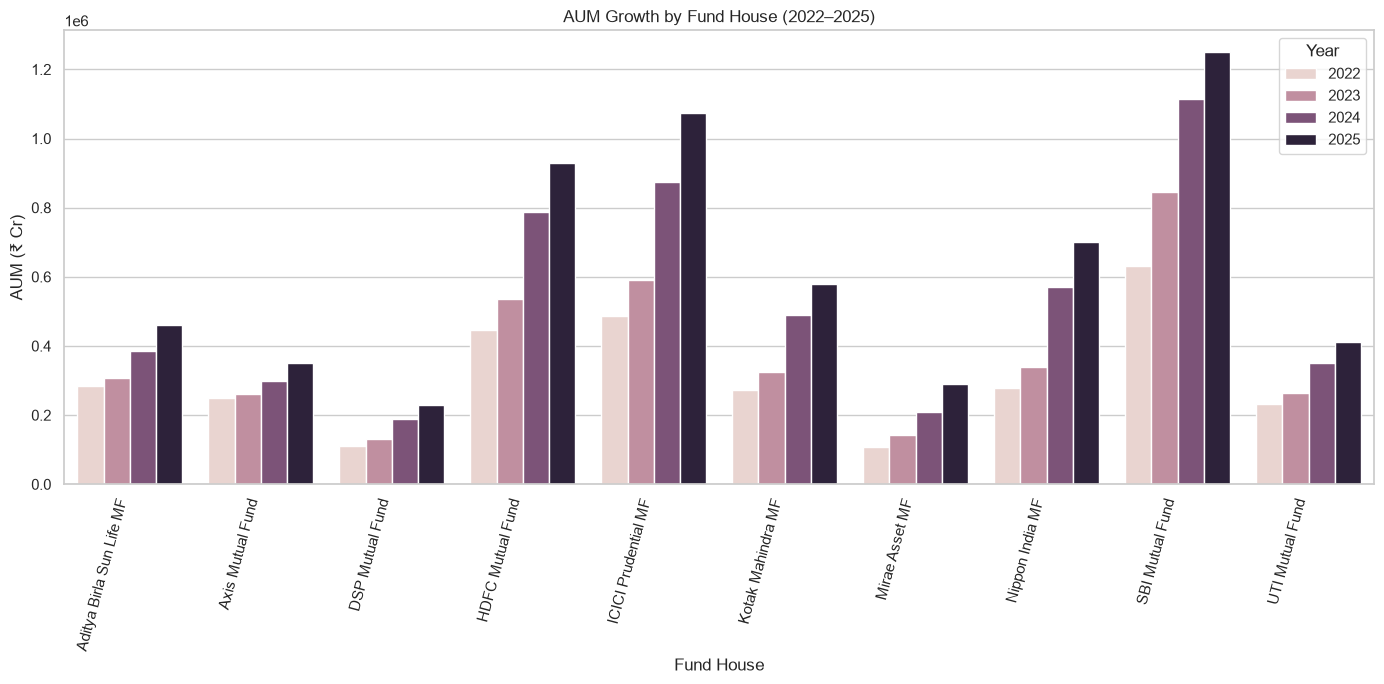

In [20]:
# Seaborn grouped bar chart
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.xticks(rotation=75, ha="right")
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Cr)")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [21]:
# SBI dominates
sbi_aum = aum_yearly[aum_yearly["fund_house"].str.contains("SBI", case=False, na=False)]
sbi_aum

,fund_house,year,aum_crore
32,SBI Mutual Fund,2022,630000
33,SBI Mutual Fund,2023,845000
34,SBI Mutual Fund,2024,1114000
35,SBI Mutual Fund,2025,1250000


### Insight 2

SBI Mutual Fund remains one of the strongest players by AUM, showing clear dominance across multiple years in the industry-level comparison.

## Section 3: SIP Inflow Time-Series (HR Requirement)

In [ ]:
# Convert month column into datetime
sip["month"] = pd.to_datetime(sip["month"], errors="coerce")

sip = sip.sort_values("month")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,1970-01-19 23:49:55.200,11517,4.91,9.10,4.80,NaN
1,1970-01-20 00:34:33.600,11438,4.93,8.20,4.85,NaN
2,1970-01-20 01:14:52.800,12328,5.09,10.50,5.01,NaN
3,1970-01-20 01:59:31.200,11863,5.48,9.52,5.12,NaN
4,1970-01-20 02:42:43.200,12286,5.55,8.10,5.15,NaN


In [23]:
# Interactive Plotly chart
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022–2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [24]:
# Highlight Highest SIP
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest SIP: ₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

### Insight 3

Monthly SIP inflows show a consistent upward trend, with the highest inflow recorded at the peak month available in the dataset.

## Section 4: Category Inflow Heatmap

In [25]:
category["month"] = pd.to_datetime(category["month"], errors="coerce")

heatmap_df = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_df.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


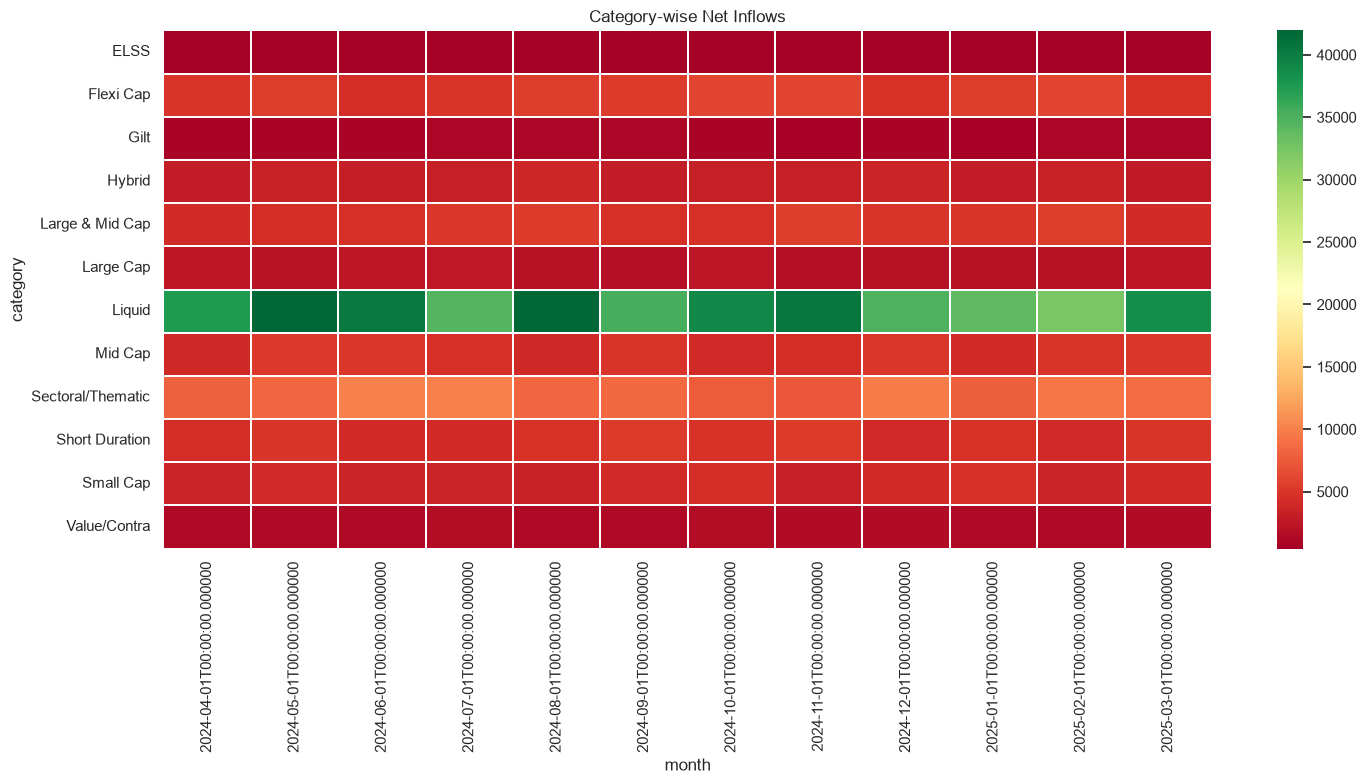

In [26]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_df,
    cmap="RdYlGn",
    linewidths=0.2
)

plt.title("Category-wise Net Inflows")

plt.tight_layout()

plt.show()

### Insight 4

Certain mutual fund categories consistently attracted stronger inflows, indicating sustained investor preference during specific market phases.

## Section 5: Investor Demographics

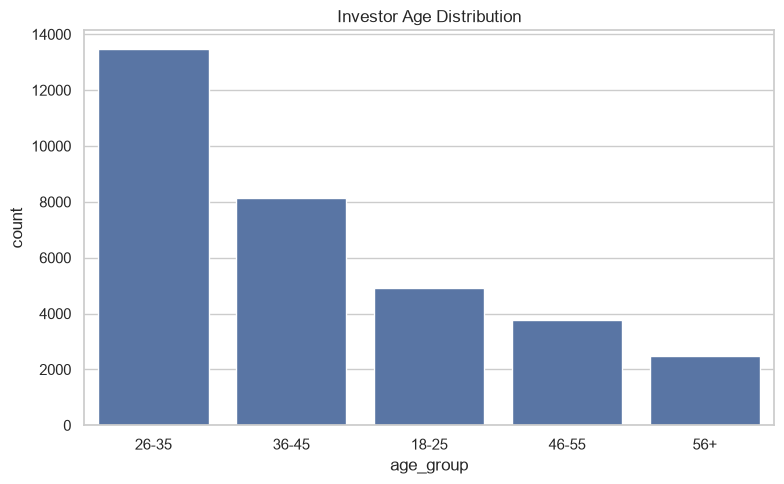

In [27]:
# Age Group Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=investor,
    x="age_group",
    order=investor["age_group"].value_counts().index
)

plt.title("Investor Age Distribution")

plt.tight_layout()

plt.show()

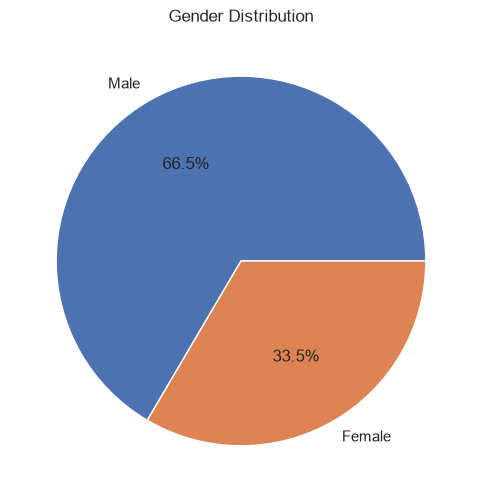

In [28]:
# Gender Distribution
gender = investor["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

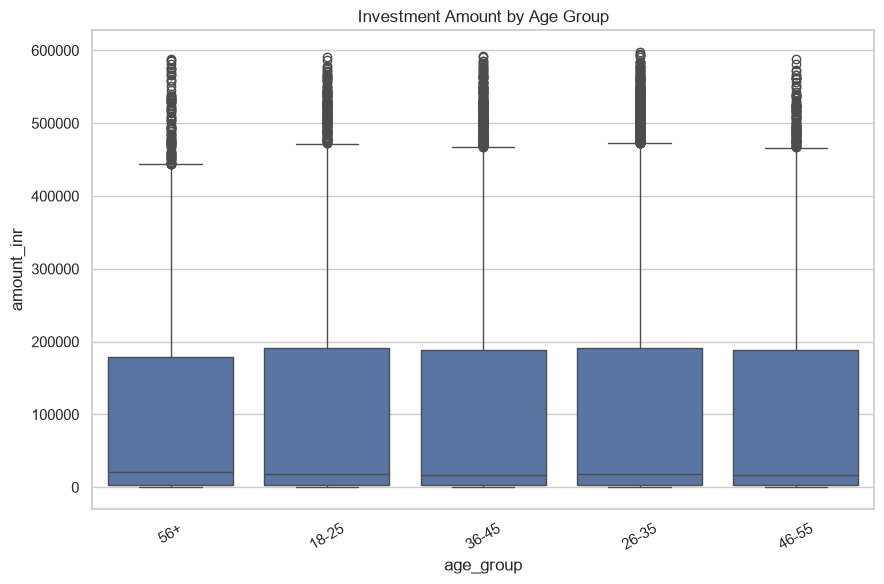

In [29]:
# SIP Amount by Age Group
plt.figure(figsize=(9,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

### Insight 5

Middle-aged investors contribute the highest investment volumes, while younger investors show wider variability in transaction sizes.

## Section 6: Geographic Distribution

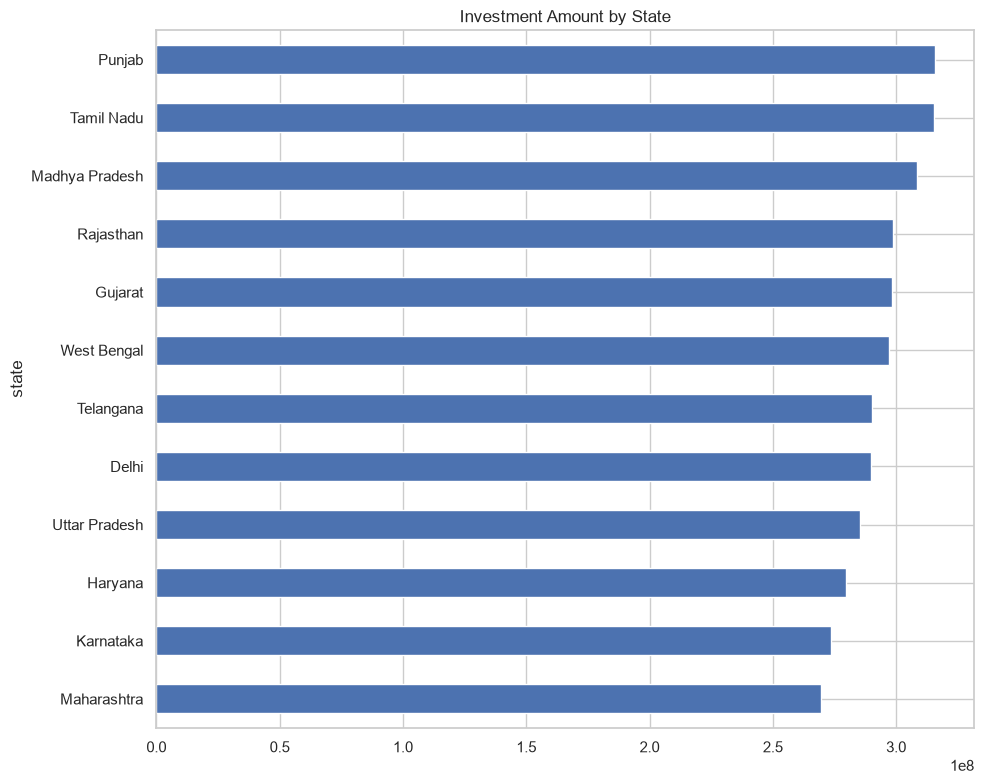

In [30]:
# State-wise Investment
state_data = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_data.plot(kind="barh")

plt.title("Investment Amount by State")

plt.tight_layout()

plt.show()

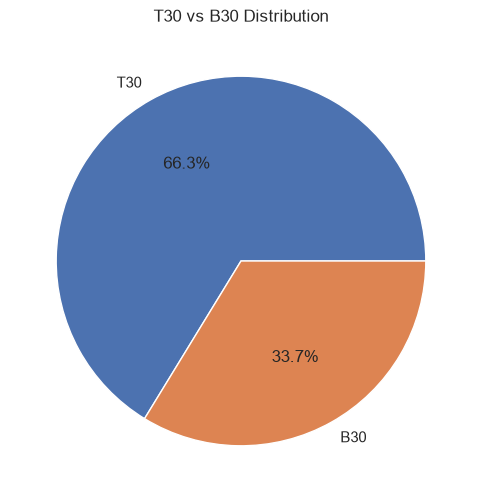

In [31]:
# T30 vs B30
tier = investor["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.show()

### Insight 6

T30 cities contribute a significant share of investments, while B30 participation demonstrates the expanding reach of mutual funds across India.

 ## Section 7: Folio Count Growth

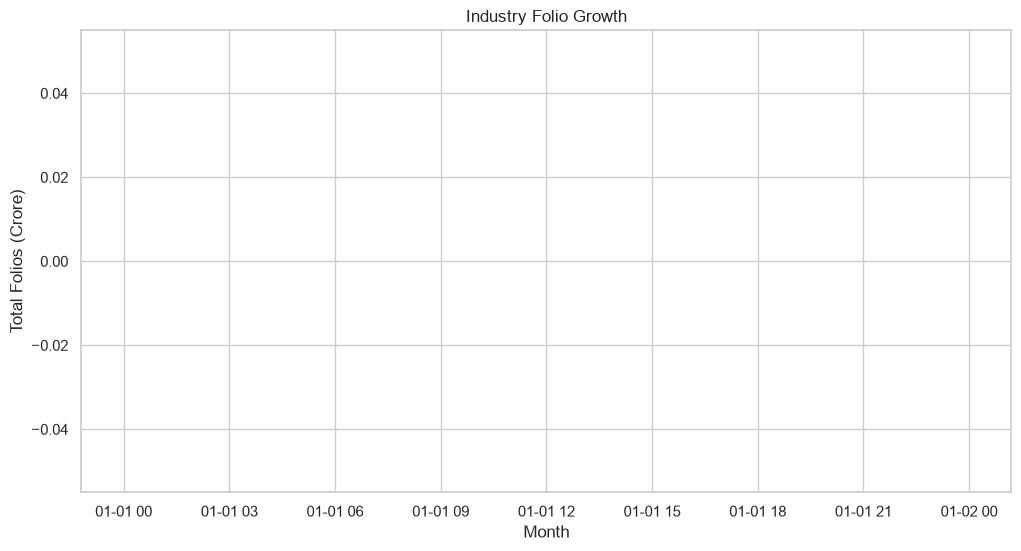

In [32]:
folio["month"] = pd.to_datetime(folio["month"], errors="coerce")

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")

plt.xlabel("Month")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

### Insight 7

The number of mutual fund folios steadily increased throughout the observed period, reflecting growing investor participation.

## Section 8: NAV Return Correlation Matrix

In [33]:
# Daily Returns
# Pivot NAV data
nav_pivot = nav_history.pivot_table(
    index="date",
    columns="scheme_code",
    values="nav"
)

# Daily percentage returns
daily_returns = nav_pivot.pct_change().dropna()

daily_returns.head()

scheme_code,100033,101206,101207,101208,102885,118632,118633,118634,118636,119092,...,120842,120843,120844,125497,125498,148567,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,


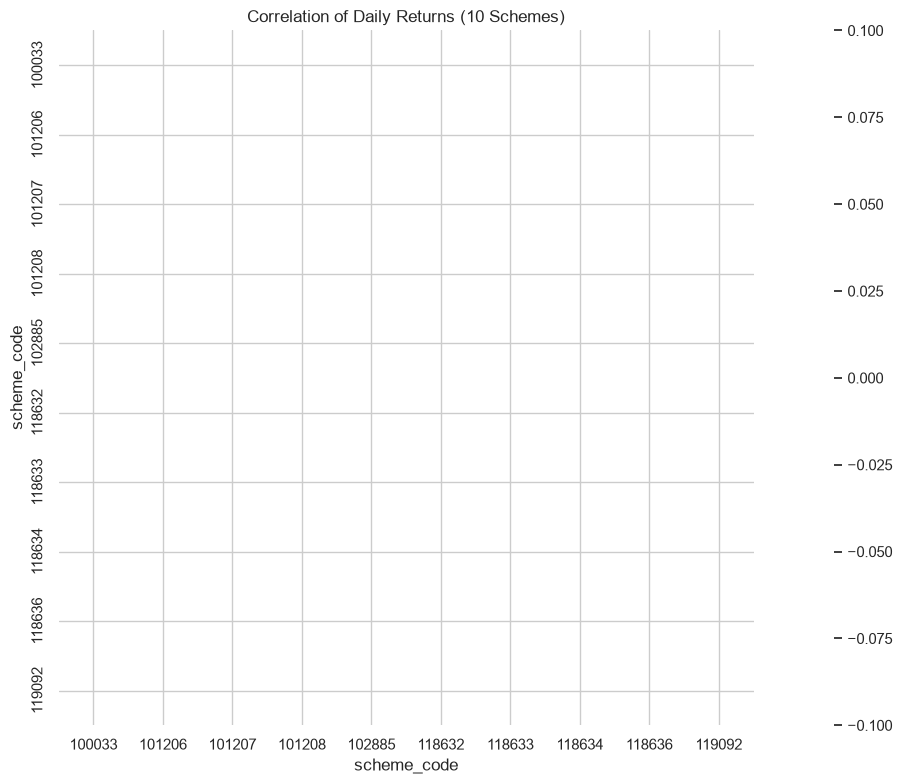

In [34]:
selected_returns = daily_returns.iloc[:, :10]

selected_returns.head()

# Correlation Matrix
corr = selected_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f"
)

plt.title("Correlation of Daily Returns (10 Schemes)")

plt.tight_layout()

plt.show()

### Insight 8

Most equity-oriented schemes exhibit positive return correlations, reflecting common exposure to broader market movements, while differences highlight diversification opportunities.

## Section 9: Sector Allocation Donut Chart

In [35]:
# Aggregate Sector Weights
sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

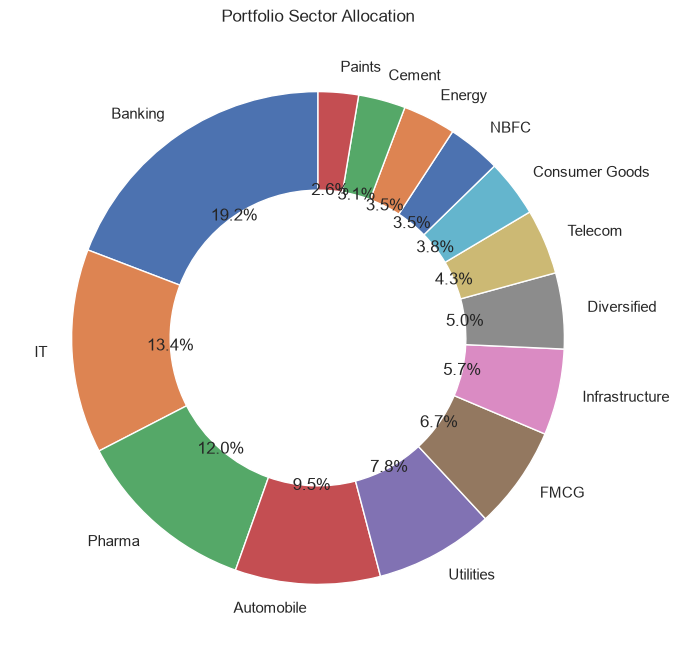

In [36]:
# Donut Chart
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Portfolio Sector Allocation")

plt.show()

### Insight 9

Financial Services, Information Technology, and Healthcare constitute the largest sector allocations across the aggregated equity portfolios.

## Section 10: Top Holdings

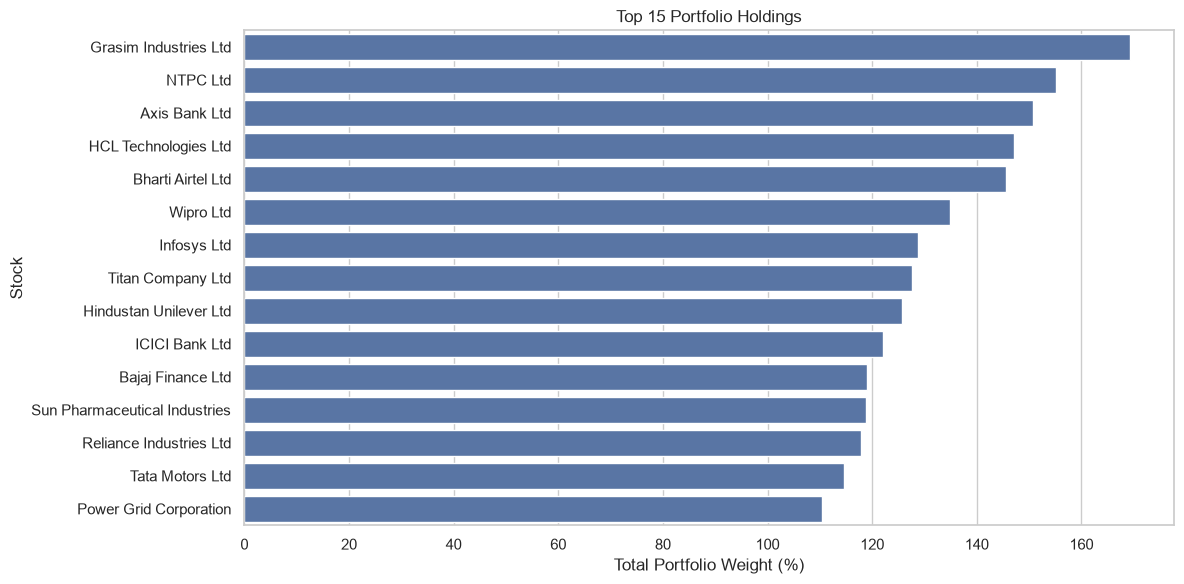

In [37]:
top_holdings = (
    portfolio.groupby("stock_name")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_holdings.values,
    y=top_holdings.index
)

plt.title("Top 15 Portfolio Holdings")

plt.xlabel("Total Portfolio Weight (%)")

plt.ylabel("Stock")

plt.tight_layout()

plt.show()

### Insight 10

A relatively small group of large-cap companies contributes a substantial proportion of the total portfolio allocation across funds.

## Section 11: Benchmark Trend

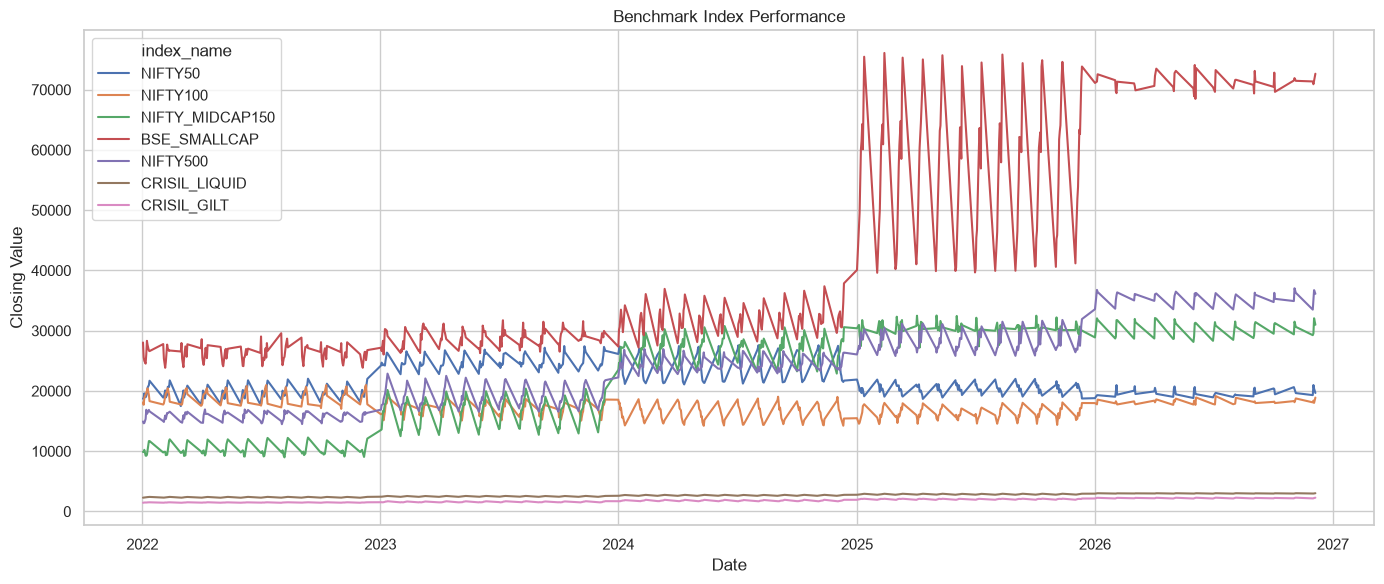

In [38]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    errors="coerce"
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=benchmark,
    x="date",
    y="close_value",
    hue="index_name"
)

plt.title("Benchmark Index Performance")

plt.xlabel("Date")

plt.ylabel("Closing Value")

plt.tight_layout()

plt.show()

### Insight 11

Major benchmark indices demonstrate long-term growth with intermittent correction periods, providing context for mutual fund performance.

## Section 12: Export Figures

In [ ]:
# For Matplotlib charts
plt.savefig(
    "../reports/charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)

# For Plotly Charts
fig.write_image(
    "../reports/charts/nav_trend_plotly.png",
    scale=3
)